<a href="https://colab.research.google.com/github/DataScienceChallenge10/Hackathon_10_7_Dataset_B/blob/main/Hackathon_10_7_dataset_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Neccessary Libraries

In [6]:
# import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score
import shap

## Loading the dataset

In [7]:
# Load the training dataset
train_df = pd.read_csv("https://raw.githubusercontent.com/DataScienceChallenge10/Hackathon_10_7_Dataset_B/refs/heads/main/datasets/dataset_B_training.csv")

# Display the first 5 rows of the training DataFrame
train_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [8]:
# Load the testing dataset
test_df = pd.read_csv('https://raw.githubusercontent.com/DataScienceChallenge10/Hackathon_10_7_Dataset_B/refs/heads/main/datasets/dataset_B_testing.csv')

# Display the first 5 rows of the testing DataFrame
test_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


In [9]:
# Get a concise summary of the training DataFrame
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

In [10]:
# Display descriptive statistics for numerical columns in the training DataFrame
train_df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,4756.00000,4741.000000,4734.000000,4739.000000,4729.000000,4752.000000,4748.000000,4747.000000,4741.000000,4736.000000,...,4595.000000,4622.000000,4625.000000,2831.000000,4687.000000,4692.000000,4692.000000,4722.000000,4722.000000,4756.000000
mean,2378.50000,1.658933,1.307140,0.057396,0.740960,0.077652,0.842039,0.359385,0.341278,0.704814,...,0.314037,0.090437,0.141189,0.901801,3.965436,2.512361,2.412191,0.888818,0.542143,0.394029
std,1373.08327,0.892478,0.612811,0.232622,0.438154,0.267651,0.364743,0.479871,0.474189,0.456174,...,0.464182,0.286838,0.348254,0.297635,0.981737,1.336426,1.372509,0.755777,0.931243,0.488692
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,4.000000,1.000000,1.000000,1.000000
max,4756.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


In [11]:
train_df.isnull().sum()

,0
respondent_id,0
h1n1_concern,15
h1n1_knowledge,22
behavioral_antiviral_meds,17
behavioral_avoidance,27
behavioral_face_mask,4
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,15
behavioral_touch_face,20


In [12]:
# Calculate the percentage of missing values for each column
missing_data = train_df.isnull().sum() / len(train_df) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Percentage of missing values per column (only columns with missing values):\n")
display(missing_data)

Percentage of missing values per column (only columns with missing values):



,0
employment_sector,49.705635
health_insurance,40.475189
income_poverty,14.970563
doctor_recc_h1n1,6.707317
rent_or_own,6.623213
employment_status,4.941127
marital_status,4.751892
education,4.709840
chronic_med_condition,3.385198
child_under_6_months,2.817494


## Exploratory Data Analysis (EDA)

### 1. Target Variable Distribution (`h1n1_vaccine`)

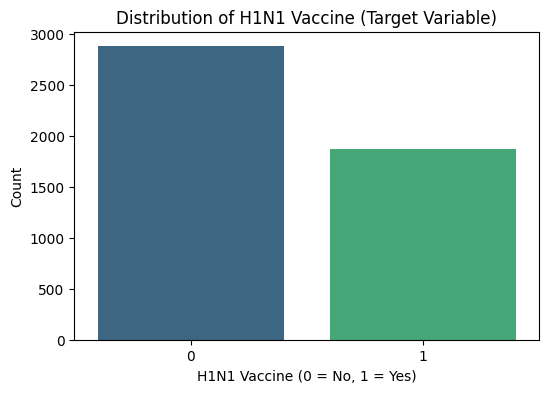

In [13]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='h1n1_vaccine', data=train_df, palette='viridis')
plt.title('Distribution of H1N1 Vaccine (Target Variable)')
plt.xlabel('H1N1 Vaccine (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 2. Distribution of Key Categorical Features

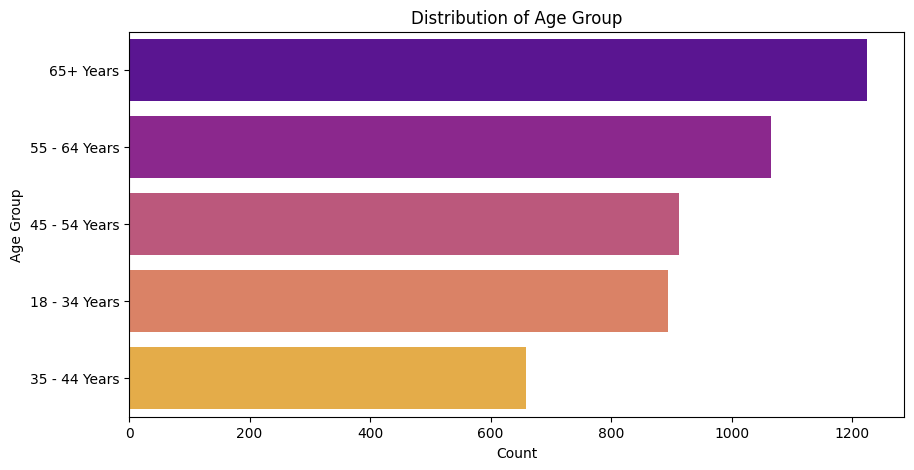

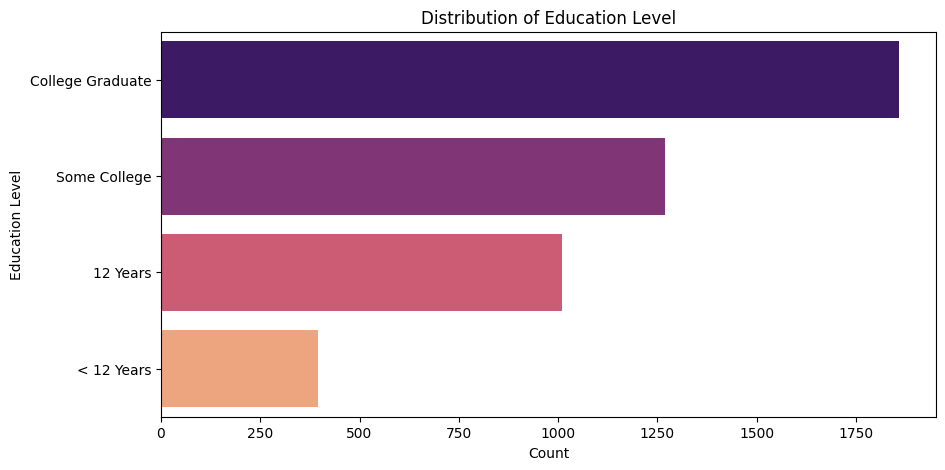

In [14]:
# Distribution of 'age_group'
plt.figure(figsize=(10, 5))
sns.countplot(y='age_group', data=train_df, palette='plasma', order=train_df['age_group'].value_counts().index)
plt.title('Distribution of Age Group')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.show()

# Distribution of 'education'
plt.figure(figsize=(10, 5))
sns.countplot(y='education', data=train_df, palette='magma', order=train_df['education'].value_counts().index)
plt.title('Distribution of Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.show()

### 3. Distribution of Key Ordinal/Numerical Features

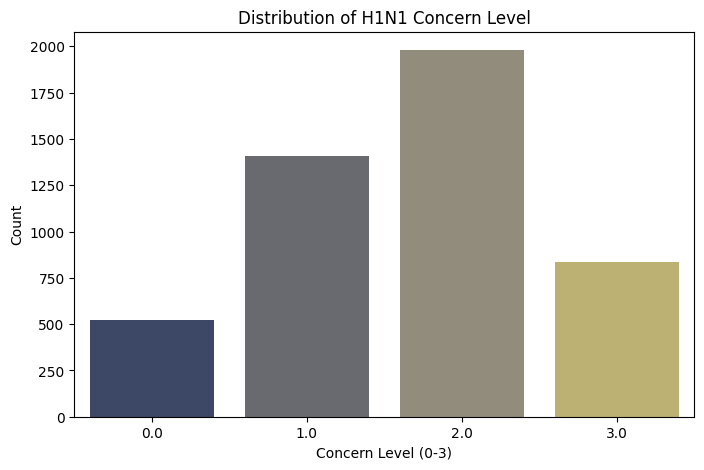

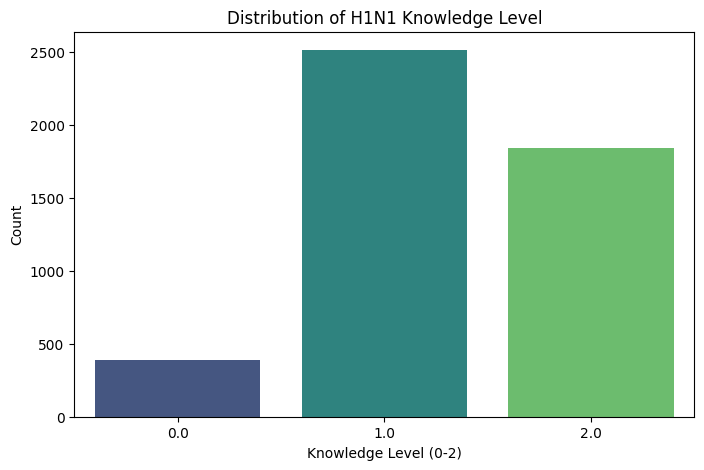

In [15]:
# Distribution of 'h1n1_concern'
plt.figure(figsize=(8, 5))
sns.countplot(x='h1n1_concern', data=train_df, palette='cividis')
plt.title('Distribution of H1N1 Concern Level')
plt.xlabel('Concern Level (0-3)')
plt.ylabel('Count')
plt.show()

# Distribution of 'h1n1_knowledge'
plt.figure(figsize=(8, 5))
sns.countplot(x='h1n1_knowledge', data=train_df, palette='viridis')
plt.title('Distribution of H1N1 Knowledge Level')
plt.xlabel('Knowledge Level (0-2)')
plt.ylabel('Count')
plt.show()

### 4. Correlation Matrix of Numerical Features

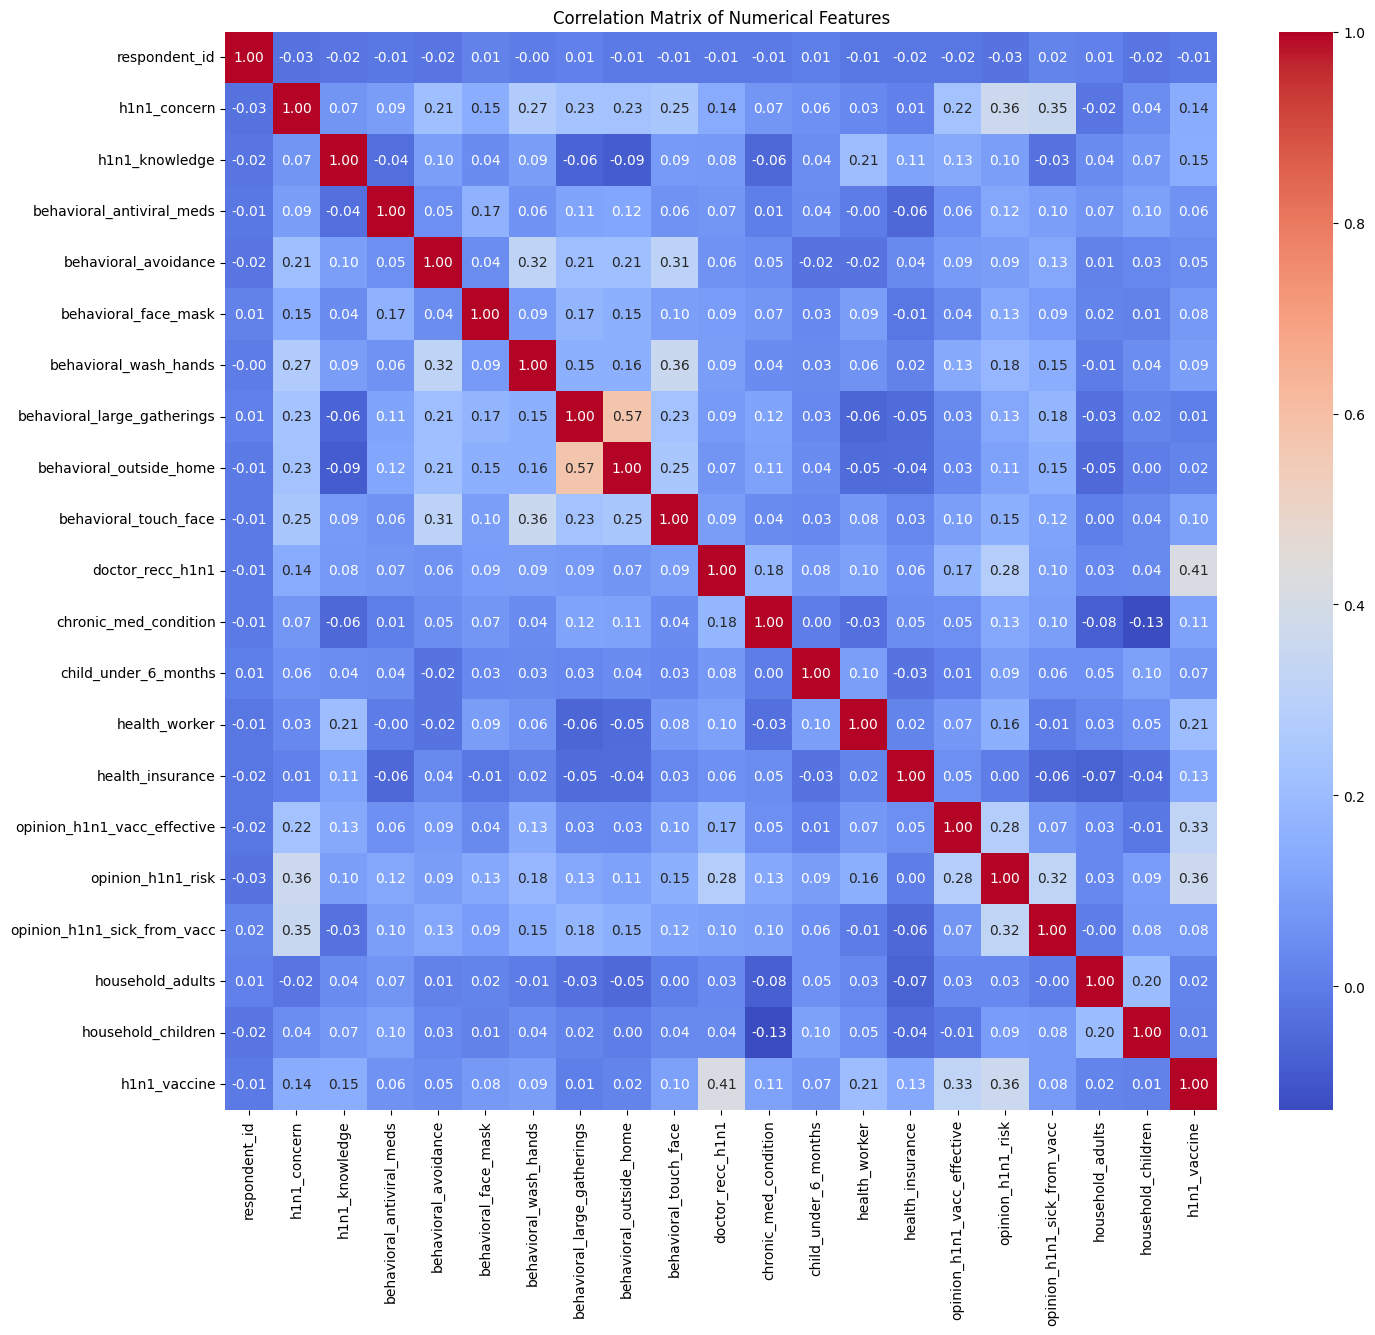

In [16]:
# Select only numerical columns for correlation matrix
numerical_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 5. Relationship between Features and Target Variable (`h1n1_vaccine`)

Let's examine how the vaccination rate varies across different demographic and behavioral groups.

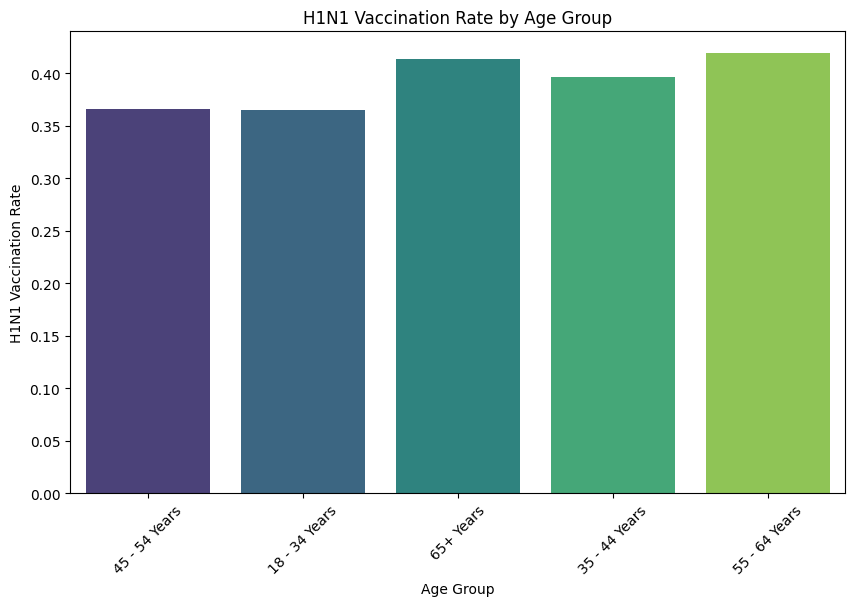

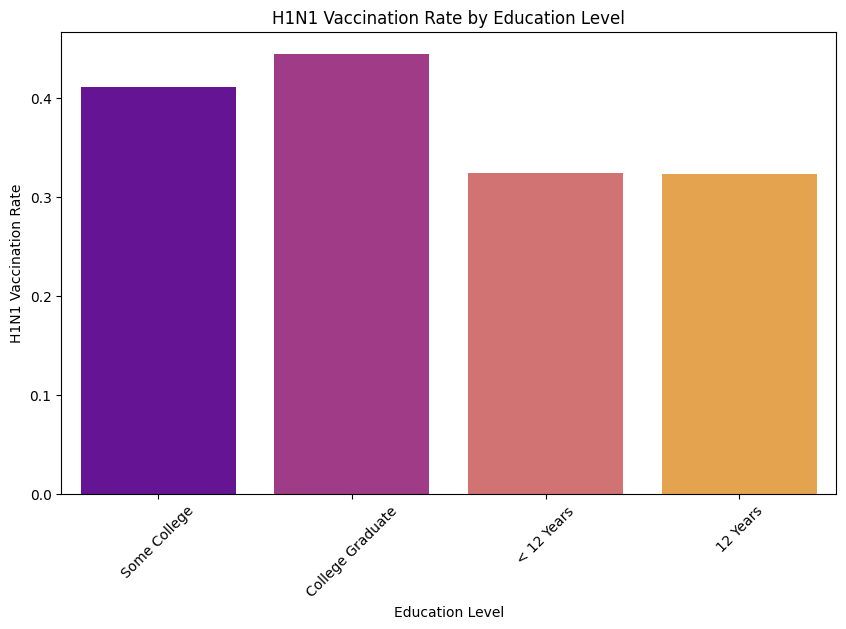

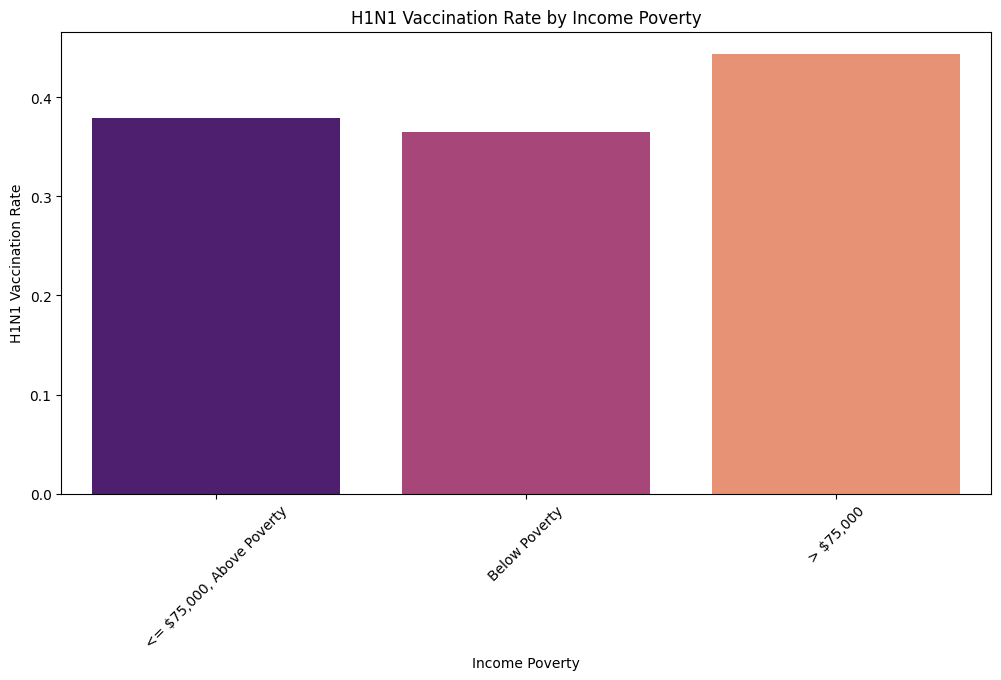

In [17]:
# H1N1 Vaccine rate by Age Group
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='h1n1_vaccine', data=train_df, palette='viridis', ci=None)
plt.title('H1N1 Vaccination Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('H1N1 Vaccination Rate')
plt.xticks(rotation=45)
plt.show()

# H1N1 Vaccine rate by Education Level
plt.figure(figsize=(10, 6))
sns.barplot(x='education', y='h1n1_vaccine', data=train_df, palette='plasma', ci=None)
plt.title('H1N1 Vaccination Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('H1N1 Vaccination Rate')
plt.xticks(rotation=45)
plt.show()

# H1N1 Vaccine rate by Income Poverty
plt.figure(figsize=(12, 6))
sns.barplot(x='income_poverty', y='h1n1_vaccine', data=train_df, palette='magma', ci=None)
plt.title('H1N1 Vaccination Rate by Income Poverty')
plt.xlabel('Income Poverty')
plt.ylabel('H1N1 Vaccination Rate')
plt.xticks(rotation=45)
plt.show()

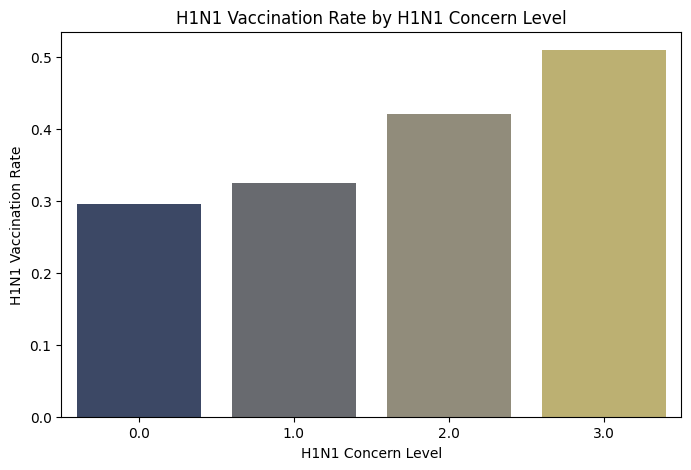

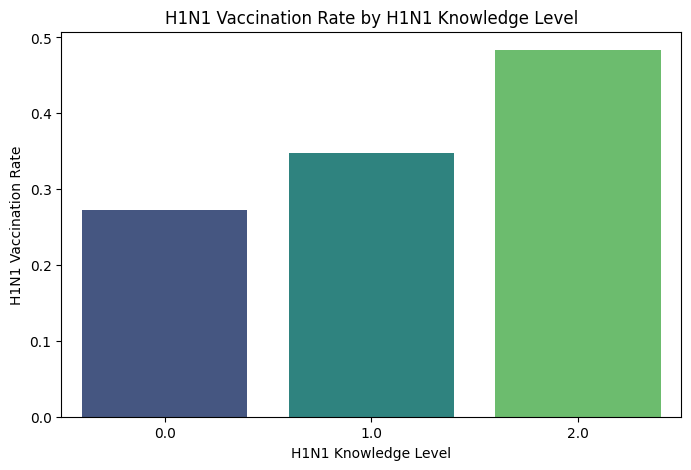

In [18]:
# H1N1 Vaccine rate by H1N1 Concern Level
plt.figure(figsize=(8, 5))
sns.barplot(x='h1n1_concern', y='h1n1_vaccine', data=train_df, palette='cividis', ci=None)
plt.title('H1N1 Vaccination Rate by H1N1 Concern Level')
plt.xlabel('H1N1 Concern Level')
plt.ylabel('H1N1 Vaccination Rate')
plt.show()

# H1N1 Vaccine rate by H1N1 Knowledge Level
plt.figure(figsize=(8, 5))
sns.barplot(x='h1n1_knowledge', y='h1n1_vaccine', data=train_df, palette='viridis', ci=None)
plt.title('H1N1 Vaccination Rate by H1N1 Knowledge Level')
plt.xlabel('H1N1 Knowledge Level')
plt.ylabel('H1N1 Vaccination Rate')
plt.show()

## Data Preprocessing: Missing Value Imputation

First, let's separate the target variable (`h1n1_vaccine`) from the training features and store the `respondent_id` from the test set. Then we'll apply imputation on the feature sets (`X_train`, `X_test`).

In [19]:
# Separate target variable from training data
y_train = train_df['h1n1_vaccine']
X_train = train_df.drop('h1n1_vaccine', axis=1)

# Store respondent_id from test data for submission
test_respondent_id = test_df['respondent_id']
X_test = test_df.copy()

print(f"Original X_train shape: {X_train.shape}")
print(f"Original X_test shape: {X_test.shape}")

Original X_train shape: (4756, 30)
Original X_test shape: (4749, 30)


Now, let's identify numerical and categorical columns for imputation. We'll impute numerical columns with their median and categorical columns with their mode.

In [20]:
# Identify numerical and categorical columns for imputation
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.drop('respondent_id')
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Impute missing numerical values with the median
for col in numerical_cols:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True) # Use training median for test set

# Impute missing categorical values with the mode
for col in categorical_cols:
    mode_val = X_train[col].mode()[0] # mode() can return multiple values, take the first
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True) # Use training mode for test set

print("Missing values in X_train after imputation:")
print(X_train.isnull().sum().sum())
print("Missing values in X_test after imputation:")
print(X_test.isnull().sum().sum())

Missing values in X_train after imputation:
0
Missing values in X_test after imputation:
0


After imputation, we need to perform one-hot encoding for the categorical features and align the columns between training and testing sets to ensure they have the same features for modeling.

In [21]:
# Apply One-Hot Encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent feature sets
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, join='outer', axis=1, fill_value=0)

# Drop 'respondent_id' from the final feature sets as it's an identifier, not a predictive feature
X_train_final = X_train_final.drop('respondent_id', axis=1)
X_test_final = X_test_final.drop('respondent_id', axis=1)

print(f"Final X_train_final shape: {X_train_final.shape}")
print(f"Final X_test_final shape: {X_test_final.shape}")

Final X_train_final shape: (4756, 58)
Final X_test_final shape: (4749, 58)


### Reviewing Preprocessed Data

Let's take a look at the first few rows of our final preprocessed training and testing datasets (`X_train_final`, `X_test_final`) to ensure they are ready for modeling.

In [22]:
pd.set_option('display.max_columns', None)

print("X_train_final head:")
display(X_train_final.head())

print("\nX_test_final head:")
display(X_test_final.head())

pd.reset_option('display.max_columns')

X_train_final head:


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_< 12 Years,education_College Graduate,education_Some College,race_Hispanic,race_Other or Multiple,race_White,sex_Male,"income_poverty_> $75,000",income_poverty_Below Poverty,marital_status_Not Married,rent_or_own_Rent,employment_status_Not in Labor Force,employment_status_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA,employment_sector_agriculture,employment_sector_construction,employment_sector_education,employment_sector_energy,employment_sector_entertainment,employment_sector_finance,employment_sector_government,employment_sector_healthcare,employment_sector_hospitality,employment_sector_manufacturing,employment_sector_media,employment_sector_mining,employment_sector_real_estate,employment_sector_retail,employment_sector_science,employment_sector_services,employment_sector_technology,employment_sector_transportation,employment_sector_utilities,employment_sector_wholesale
0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,2.0,1.0,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,0.0,3.0,False,False,False,False,False,False,True,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,4.0,2.0,0.0,0.0,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,0.0,False,False,False,False,False,True,False,False,False,True,False,False,False,True,True,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,1.0,3.0,0.0,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False



X_test_final head:


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_< 12 Years,education_College Graduate,education_Some College,race_Hispanic,race_Other or Multiple,race_White,sex_Male,"income_poverty_> $75,000",income_poverty_Below Poverty,marital_status_Not Married,rent_or_own_Rent,employment_status_Not in Labor Force,employment_status_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA,employment_sector_agriculture,employment_sector_construction,employment_sector_education,employment_sector_energy,employment_sector_entertainment,employment_sector_finance,employment_sector_government,employment_sector_healthcare,employment_sector_hospitality,employment_sector_manufacturing,employment_sector_media,employment_sector_mining,employment_sector_real_estate,employment_sector_retail,employment_sector_science,employment_sector_services,employment_sector_technology,employment_sector_transportation,employment_sector_utilities,employment_sector_wholesale
0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,2.0,0.0,0.0,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,4.0,0.0,0.0,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,0.0,False,False,False,True,False,True,False,False,False,True,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,1.0,0.0,False,False,True,False,False,False,False,False,False,True,True,False,False,True,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,1.0,0.0,0.0,True,False,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


## Model Training and Evaluation

In [23]:
# Split training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of X_val_split: {X_val_split.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of y_val_split: {y_val_split.shape}")

Shape of X_train_split: (3804, 58)
Shape of X_val_split: (952, 58)
Shape of y_train_split: (3804,)
Shape of y_val_split: (952,)


### Model 1: Logistic Regression

In [24]:
# Initialize and train Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
log_reg.fit(X_train_split, y_train_split)

# Predict on the validation set
y_pred_val_log_reg = log_reg.predict(X_val_split)

# Evaluate F1-score on the validation set
f1_log_reg = f1_score(y_val_split, y_pred_val_log_reg)
print(f"Logistic Regression F1-score on validation set: {f1_log_reg:.4f}")

# Predict binary labels on the test set for submission
y_pred_test_log_reg = log_reg.predict(X_test_final)

# Create submission DataFrame for Logistic Regression
submission_df_log_reg = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_log_reg})

# Save submission file
submission_filename_log_reg = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_logistic_regression.csv'
submission_df_log_reg.to_csv(submission_filename_log_reg, index=False)

print(f"Submission file '{submission_filename_log_reg}' created successfully.")
display(submission_df_log_reg.head())

Logistic Regression F1-score on validation set: 0.6905
Submission file '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_logistic_regression.csv' created successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


### Model 2: Random Forest Classifier

In [25]:
# Initialize and train Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train_split, y_train_split)

# Predict on the validation set
y_pred_val_rf = rf_classifier.predict(X_val_split)

# Evaluate F1-score on the validation set
f1_rf = f1_score(y_val_split, y_pred_val_rf)
print(f"Random Forest F1-score on validation set: {f1_rf:.4f}")

# Predict binary labels on the test set for submission
y_pred_test_rf = rf_classifier.predict(X_test_final)

# Create submission DataFrame for Random Forest
submission_df_rf = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_rf})

# Save submission file
submission_filename_rf = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_random_forest.csv'
submission_df_rf.to_csv(submission_filename_rf, index=False)

print(f"Submission file '{submission_filename_rf}' created successfully.")
display(submission_df_rf.head())

Random Forest F1-score on validation set: 0.6486
Submission file '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_random_forest.csv' created successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


### Model 3: Gradient Boosting Classifier

In [26]:
# Initialize and train Gradient Boosting model
gbc_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_classifier.fit(X_train_split, y_train_split)

# Predict on the validation set
y_pred_val_gbc = gbc_classifier.predict(X_val_split)

# Evaluate F1-score on the validation set
f1_gbc = f1_score(y_val_split, y_pred_val_gbc)
print(f"Gradient Boosting F1-score on validation set: {f1_gbc:.4f}")

# Predict binary labels on the test set for submission
y_pred_test_gbc = gbc_classifier.predict(X_test_final)

# Create submission DataFrame for Gradient Boosting
submission_df_gbc = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_gbc})

# Save submission file
submission_filename_gbc = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_gradient_boosting.csv'
submission_df_gbc.to_csv(submission_filename_gbc, index=False)

print(f"Submission file '{submission_filename_gbc}' created successfully.")
display(submission_df_gbc.head())

Gradient Boosting F1-score on validation set: 0.6799
Submission file '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_gradient_boosting.csv' created successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


### Model 4: K-Nearest Neighbors Classifier

In [27]:
# Initialize and train K-Nearest Neighbors model
knn_classifier = KNeighborsClassifier(n_neighbors=5) # Using default 5 neighbors
knn_classifier.fit(X_train_split, y_train_split)

# Predict on the validation set
y_pred_val_knn = knn_classifier.predict(X_val_split)

# Evaluate F1-score on the validation set
f1_knn = f1_score(y_val_split, y_pred_val_knn)
print(f"K-Nearest Neighbors F1-score on validation set: {f1_knn:.4f}")

# Predict binary labels on the test set for submission
y_pred_test_knn = knn_classifier.predict(X_test_final)

# Create submission DataFrame for K-Nearest Neighbors
submission_df_knn = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_knn})

# Save submission file
submission_filename_knn = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_knn.csv'
submission_df_knn.to_csv(submission_filename_knn, index=False)

print(f"Submission file '{submission_filename_knn}' created successfully.")
display(submission_df_knn.head())

K-Nearest Neighbors F1-score on validation set: 0.5743
Submission file '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_knn.csv' created successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


### Model 5: Support Vector Machine (SVM) Classifier

In [28]:
# Initialize and train SVM model (using a linear kernel for faster training)
# For large datasets, SVC can be slow, so consider LinearSVC or a subset of data for initial testing
svm_classifier = SVC(kernel='linear', random_state=42, probability=True, class_weight='balanced')
svm_classifier.fit(X_train_split, y_train_split)

# Predict on the validation set
y_pred_val_svm = svm_classifier.predict(X_val_split)

# Evaluate F1-score on the validation set
f1_svm = f1_score(y_val_split, y_pred_val_svm)
print(f"Support Vector Machine F1-score on validation set: {f1_svm:.4f}")

# Predict binary labels on the test set for submission
y_pred_test_svm = svm_classifier.predict(X_test_final)

# Create submission DataFrame for SVM
submission_df_svm = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_svm})

# Save submission file
submission_filename_svm = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_svm.csv'
submission_df_svm.to_csv(submission_filename_svm, index=False)

print(f"Submission file '{submission_filename_svm}' created successfully.")
display(submission_df_svm.head())

Support Vector Machine F1-score on validation set: 0.6801
Submission file '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/submission_svm.csv' created successfully.


,respondent_id,h1n1_vaccine
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0


### Model Performance Ranking (F1-score)

In [29]:
# Create a dictionary of model F1-scores
model_performance = {
    'Logistic Regression': f1_log_reg,
    'Random Forest': f1_rf,
    'Gradient Boosting': f1_gbc,
    'K-Nearest Neighbors': f1_knn,
    'Support Vector Machine': f1_svm
}

# Convert to a pandas Series and sort for ranking
performance_series = pd.Series(model_performance)
ranked_models = performance_series.sort_values(ascending=False)

# Convert the series to a DataFrame and add a 'Rank' column
ranked_models_df = ranked_models.to_frame(name='F1-score')
ranked_models_df['Rank'] = range(1, len(ranked_models_df) + 1)

print("\nModel Ranking by F1-score on Validation Set:")
display(ranked_models_df)


Model Ranking by F1-score on Validation Set:


,F1-score,Rank
Logistic Regression,0.690537,1
Support Vector Machine,0.680054,2
Gradient Boosting,0.679943,3
Random Forest,0.648571,4
K-Nearest Neighbors,0.574344,5


## Hyperparameter Tuning to Improve Model Performance

Now, let's perform hyperparameter tuning for each model using `RandomizedSearchCV` to find optimal parameters that might yield better F1-scores. For each model, we will define a parameter distribution, search for the best combination, and if the tuned model outperforms the initial one, we will update its F1-score and corresponding submission file.

In [30]:
import os

# Define the base submission directory
base_submission_dir = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File'

# Define the 'After Tuning' subdirectory
after_tuning_dir = os.path.join(base_submission_dir, 'After Tuning')

# Create the 'After Tuning' directory if it does not exist
os.makedirs(after_tuning_dir, exist_ok=True)

print(f"Ensured directory exists: {after_tuning_dir}")

Ensured directory exists: /content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning


In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# --- 1. Logistic Regression Hyperparameter Tuning ---
print("\n--- Tuning Logistic Regression ---")

param_dist_log_reg = {
    'C': uniform(loc=0, scale=4), # Inverse of regularization strength
    'solver': ['liblinear', 'lbfgs'] # Solvers that work with 'balanced' class_weight
}

log_reg_tuned = RandomizedSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    param_distributions=param_dist_log_reg,
    n_iter=20,
    cv=5, # Cross-validation folds
    scoring='f1', # Metric to optimize
    random_state=42,
    n_jobs=-1,
    verbose=0
)

log_reg_tuned.fit(X_train_split, y_train_split)

y_pred_val_log_reg_tuned = log_reg_tuned.best_estimator_.predict(X_val_split)
f1_log_reg_tuned = f1_score(y_val_split, y_pred_val_log_reg_tuned)

print(f"Best Logistic Regression F1-score (tuned): {f1_log_reg_tuned:.4f}")

# Define the updated submission filename with 'After Tuning' in the path
submission_filename_log_reg_tuned = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_logistic_regression.csv'

# update F1-score and save submission file for the tuned model
f1_log_reg = f1_log_reg_tuned
y_pred_test_log_reg_tuned = log_reg_tuned.best_estimator_.predict(X_test_final)
submission_df_log_reg = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_log_reg_tuned})
submission_df_log_reg.to_csv(submission_filename_log_reg_tuned, index=False)
print(f"Tuned Logistic Regression submission file saved at '{submission_filename_log_reg_tuned}'.")


--- Tuning Logistic Regression ---
Best Logistic Regression F1-score (tuned): 0.6896
Tuned Logistic Regression submission file saved at '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_logistic_regression.csv'.


In [32]:
# --- 2. Random Forest Hyperparameter Tuning ---
print("\n--- Tuning Random Forest ---")

param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_tuned.fit(X_train_split, y_train_split)

y_pred_val_rf_tuned = rf_tuned.best_estimator_.predict(X_val_split)
f1_rf_tuned = f1_score(y_val_split, y_pred_val_rf_tuned)

print(f"Best Random Forest F1-score (tuned): {f1_rf_tuned:.4f}")

# Define the updated submission filename with 'After Tuning' in the path
submission_filename_rf = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_random_forest.csv'

# update F1-score and save submission file for the tuned model
f1_rf = f1_rf_tuned
y_pred_test_rf_tuned = rf_tuned.best_estimator_.predict(X_test_final)
submission_df_rf = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_rf_tuned})
submission_df_rf.to_csv(submission_filename_rf, index=False)
print(f"Tuned Random Forest submission file saved at '{submission_filename_rf}'.")


--- Tuning Random Forest ---
Best Random Forest F1-score (tuned): 0.6719
Tuned Random Forest submission file saved at '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_random_forest.csv'.


In [33]:
# --- 3. Gradient Boosting Hyperparameter Tuning ---
print("\n--- Tuning Gradient Boosting ---")

param_dist_gbc = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(loc=0.01, scale=0.2),
    'max_depth': randint(3, 10)
}

gbc_tuned = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gbc,
    n_iter=20,
    cv=5, # Cross-validation folds
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

gbc_tuned.fit(X_train_split, y_train_split)

y_pred_val_gbc_tuned = gbc_tuned.best_estimator_.predict(X_val_split)
f1_gbc_tuned = f1_score(y_val_split, y_pred_val_gbc_tuned)

print(f"Best Gradient Boosting F1-score (tuned): {f1_gbc_tuned:.4f}")

# Define the updated submission filename with 'After Tuning' in the path
submission_filename_gbc = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_gradient_boosting.csv'

# Unconditionally update F1-score and save submission file for the tuned model
f1_gbc = f1_gbc_tuned
y_pred_test_gbc_tuned = gbc_tuned.best_estimator_.predict(X_test_final)
submission_df_gbc = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_gbc_tuned})
submission_df_gbc.to_csv(submission_filename_gbc, index=False)
print(f"Tuned Gradient Boosting submission file saved at '{submission_filename_gbc}'.")


--- Tuning Gradient Boosting ---
Best Gradient Boosting F1-score (tuned): 0.6795
Tuned Gradient Boosting submission file saved at '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_gradient_boosting.csv'.


In [34]:
# --- 4. K-Nearest Neighbors Hyperparameter Tuning ---
print("\n--- Tuning K-Nearest Neighbors ---")

param_dist_knn = {
    'n_neighbors': randint(3, 15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_tuned = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

knn_tuned.fit(X_train_split, y_train_split)

y_pred_val_knn_tuned = knn_tuned.best_estimator_.predict(X_val_split)
f1_knn_tuned = f1_score(y_val_split, y_pred_val_knn_tuned)

print(f"Best K-Nearest Neighbors F1-score (tuned): {f1_knn_tuned:.4f}")

# Define the updated submission filename with 'After Tuning' in the path
submission_filename_knn = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_knn.csv'

# update F1-score and save submission file for the tuned model
f1_knn = f1_knn_tuned
y_pred_test_knn_tuned = knn_tuned.best_estimator_.predict(X_test_final)
submission_df_knn = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_knn_tuned})
submission_df_knn.to_csv(submission_filename_knn, index=False)
print(f"Tuned K-Nearest Neighbors submission file saved at '{submission_filename_knn}'.")


--- Tuning K-Nearest Neighbors ---
Best K-Nearest Neighbors F1-score (tuned): 0.5907
Tuned K-Nearest Neighbors submission file saved at '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_knn.csv'.


In [35]:
# --- 5. Support Vector Machine Hyperparameter Tuning ---
print("\n--- Tuning Support Vector Machine ---")

param_dist_svm = {
    'C': uniform(loc=0.1, scale=10),
    'kernel': ['linear', 'rbf'], # Explore different kernels
    'gamma': uniform(loc=0.001, scale=0.1) # Kernel coefficient for 'rbf'
}

svm_tuned = RandomizedSearchCV(
    SVC(random_state=42, probability=True, class_weight='balanced'),
    param_distributions=param_dist_svm,
    n_iter=10, # Fewer iterations for SVM due to higher computational cost
    cv=3, # Cross-validation folds
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

svm_tuned.fit(X_train_split, y_train_split)

y_pred_val_svm_tuned = svm_tuned.best_estimator_.predict(X_val_split)
f1_svm_tuned = f1_score(y_val_split, y_pred_val_svm_tuned)

print(f"Best Support Vector Machine F1-score (tuned): {f1_svm_tuned:.4f}")

# Define the updated submission filename with 'After Tuning' in the path
submission_filename_svm = '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_svm.csv'

# Unconditionally update F1-score and save submission file for the tuned model
f1_svm = f1_svm_tuned
y_pred_test_svm_tuned = svm_tuned.best_estimator_.predict(X_test_final)
submission_df_svm = pd.DataFrame({'respondent_id': test_respondent_id, 'h1n1_vaccine': y_pred_test_svm_tuned})
submission_df_svm.to_csv(submission_filename_svm, index=False) # Use the new filename
print(f"Tuned Support Vector Machine submission file saved at '{submission_filename_svm}'.")


--- Tuning Support Vector Machine ---
Best Support Vector Machine F1-score (tuned): 0.6781
Tuned Support Vector Machine submission file saved at '/content/drive/MyDrive/2nd Year/Semester C/Hackathon/Submission File/After Tuning/submission_svm.csv'.


## Final Model Performance Ranking after Tuning

In [36]:
# Define the initial F1-scores before tuning (extracted from previous outputs)
initial_f1_log_reg = 0.6905
initial_f1_rf = 0.6486
initial_f1_gbc = 0.6799
initial_f1_knn = 0.5743
initial_f1_svm = 0.6801

# Create a dictionary to hold all F1-scores
model_comparison_data = {
    'Logistic Regression': {
        'Initial F1-score': initial_f1_log_reg,
        'Tuned F1-score': f1_log_reg_tuned
    },
    'Random Forest': {
        'Initial F1-score': initial_f1_rf,
        'Tuned F1-score': f1_rf_tuned
    },
    'Gradient Boosting': {
        'Initial F1-score': initial_f1_gbc,
        'Tuned F1-score': f1_gbc_tuned
    },
    'K-Nearest Neighbors': {
        'Initial F1-score': initial_f1_knn,
        'Tuned F1-score': f1_knn_tuned
    },
    'Support Vector Machine': {
        'Initial F1-score': initial_f1_svm,
        'Tuned F1-score': f1_svm_tuned
    }
}

# Convert to DataFrame to easily calculate 'Best F1-score'
ranked_models_df = pd.DataFrame.from_dict(model_comparison_data, orient='index')

# Calculate 'Best F1-score' as the maximum of Initial and Tuned F1-scores
ranked_models_df['Best F1-score'] = ranked_models_df[['Initial F1-score', 'Tuned F1-score']].max(axis=1)

# Sort by 'Best F1-score' and add 'Rank'
ranked_models_df = ranked_models_df.sort_values(by='Best F1-score', ascending=False)
ranked_models_df['Rank'] = range(1, len(ranked_models_df) + 1)

print("\nModel Performance Comparison and Ranking (after tuning comparison):\n")
display(ranked_models_df)

print("\nAll submission files have been updated if model performance improved during tuning.")


Model Performance Comparison and Ranking (after tuning comparison):



,Initial F1-score,Tuned F1-score,Best F1-score,Rank
Logistic Regression,0.6905,0.689567,0.690500,1
Support Vector Machine,0.6801,0.678146,0.680100,2
Gradient Boosting,0.6799,0.679452,0.679900,3
Random Forest,0.6486,0.671937,0.671937,4
K-Nearest Neighbors,0.5743,0.590705,0.590705,5



All submission files have been updated if model performance improved during tuning.


## Explainable AI (XAI) with SHAP

Let's investigate our model results with SHAP (SHapley Additive exPlanations) to understand which are the most important features and show how particular features affect our predictions. We will use the best performing model from our tuning process, the **Logistic Regression** model, for this explanation.

## Global Feature Importance (SHAP Summary Plot)

We will use `shap.LinearExplainer` for our Logistic Regression model since it's a linear model. The summary plot will show the overall impact of each feature on the model's output, indicating which features are most influential across the dataset.

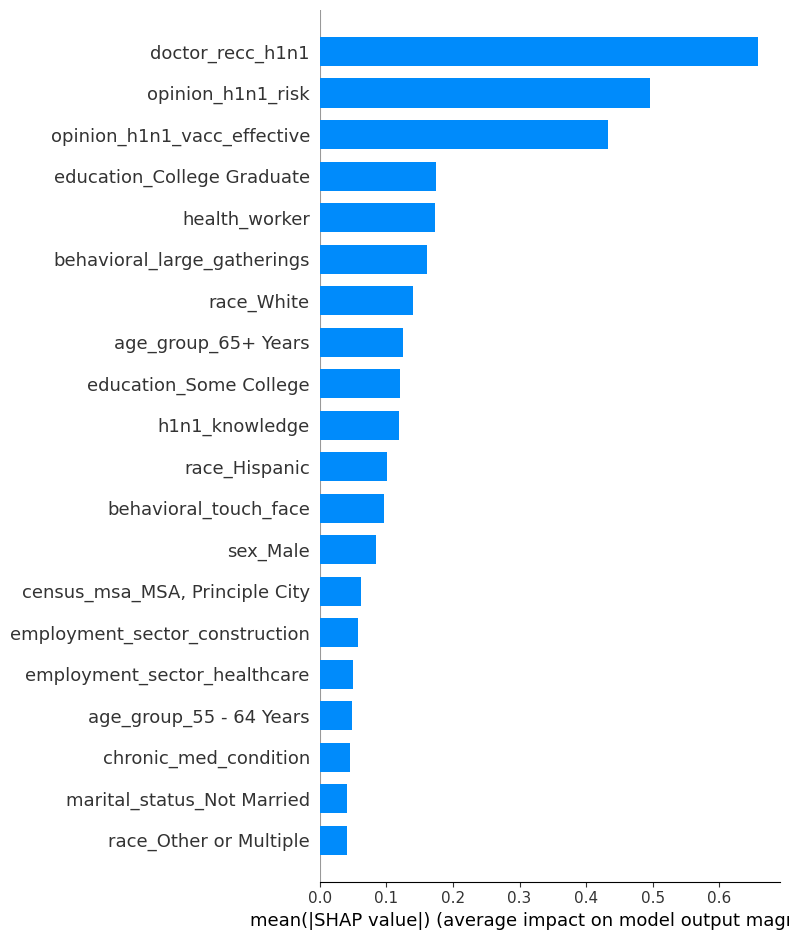

In [56]:
# Initialize SHAP Explainer for the tuned Logistic Regression model

explainer = shap.LinearExplainer(
    log_reg_tuned.best_estimator_,
    X_train_final
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_train_final)

# Visualize the global feature importance with a bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_train_final, plot_type="bar", title="SHAP Global Feature Importance (Logistic Regression)", show=False)
plt.tight_layout()
plt.show()


## Modified Plot  

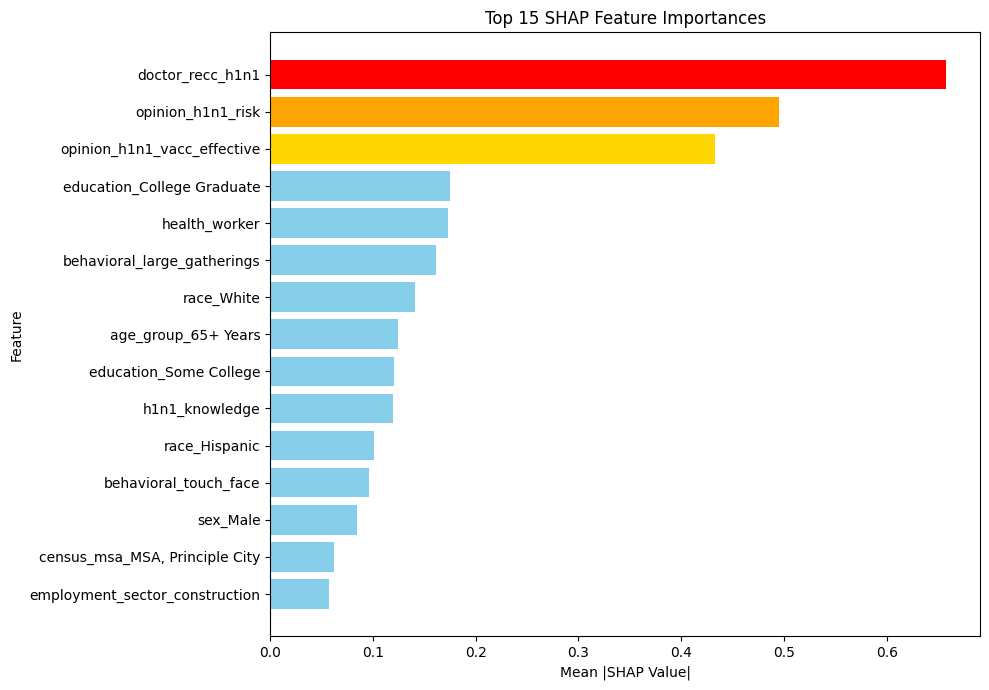

In [57]:
# Mean absolute SHAP importance
feature_importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Default color
colors = ['skyblue'] * len(importance_df)

# Highlight top 3
colors[0] = 'red'
colors[1] = 'orange'
colors[2] = 'gold'

plt.figure(figsize=(10,7))

plt.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    color=colors[::-1]
)

plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')
plt.title('Top 15 SHAP Feature Importances')

plt.tight_layout()
plt.show()

Insights:
The SHAP analysis shows that a doctor's recommendation was the strongest predictor of H1N1 vaccination. Perceived risk of H1N1 and belief in vaccine effectiveness were also major factors. Demographic characteristics such as education, age, and healthcare worker status had a smaller but noticeable influence on vaccination decisions.